In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

#from wordcloud import WordCloud

# Display settings
pd.set_option('display.max_columns', None)

# Style
sns.set_style('whitegrid')

In [2]:
df = pd.read_csv('MASTER_RAW_kenya_fintech.csv') #loading dataset
df.head() #preview of the first 5 rows of the dataset

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,app_name
0,695de54e-4b85-4669-ae8c-ad2fdf16667e,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"The app still has issues on OTP, because I hav...",1,0,5.1.7,2026-05-11 11:38:40,NaN,NaN,5.1.7,mpesa
1,acd5c061-de13-474b-8645-f628044f2a50,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,si everytime nitakuwa na bundles za ku check m...,2,0,5.1.1,2026-05-11 11:22:24,NaN,NaN,5.1.1,mpesa
2,6f9f52e9-0a00-4f70-a1cc-7687f28465a3,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,this is the stupidest app ever from saf. the w...,1,0,5.1.7,2026-05-11 11:16:47,NaN,NaN,5.1.7,mpesa
3,4a605b22-efc1-4641-b79e-e166b4a7b2e4,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Life must go on without this useless app. It u...,1,0,1.14.2,2026-05-11 11:01:23,NaN,NaN,1.14.2,mpesa
4,fd284f23-d966-4be5-b421-a1f0e14c1e13,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,the upgrade is terrible,1,0,NaN,2026-05-11 10:45:52,NaN,NaN,NaN,mpesa


- Understanding dataset size helps estimate the scale of customer feedback being analyzed. A larger dataset improves the reliability of insights and model predictions.

In [3]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(53507, 12)


To identify available features in the dataset, ensuring that important fields such as review text, ratings, and app names are present for analysis.

In [4]:
df.columns

Index(['reviewId', 'userName', 'userImage', 'content', 'score',
       'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent',
       'repliedAt', 'appVersion', 'app_name'],
      dtype='str')

In [5]:
print('....Missing values per column....')
df.isnull().sum() #checking missing values


....Missing values per column....


reviewId                    0
userName                    0
userImage                   0
content                     1
score                       0
thumbsUpCount               0
reviewCreatedVersion     6164
at                          0
replyContent            29574
repliedAt               29574
appVersion               6164
app_name                    0
dtype: int64

To check apps in the dataset

In [6]:
df['app_name'].unique()

<StringArray>
['mpesa', 'mysafaricom', 'kcb', 'equity', 'tala', 'branch']
Length: 6, dtype: str

1. Count Reviews Per App

- Review volume helps measure customer engagement and app popularity. High review counts may indicate a large customer base or increased customer concern.

app_name
mpesa          10000
mysafaricom    10000
equity         10000
tala           10000
branch         10000
kcb             3507
Name: count, dtype: int64


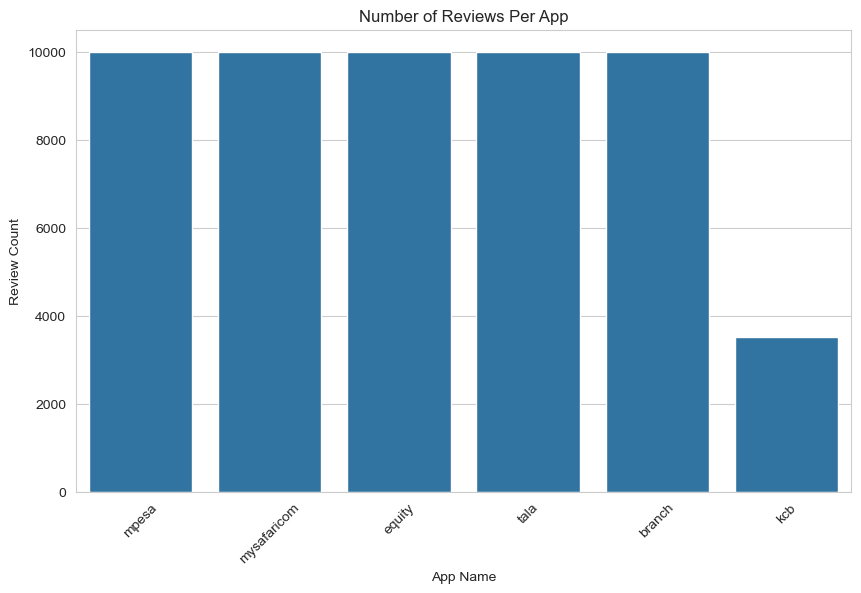

In [7]:
reviews_per_app = df['app_name'].value_counts()

print(reviews_per_app)

plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='app_name',
    order=df['app_name'].value_counts().index
)

plt.title('Number of Reviews Per App')
plt.xlabel('App Name')
plt.ylabel('Review Count')

plt.xticks(rotation=45)

plt.show()

2. Analyzing Star Rating Distribution
- Star ratings provide a direct measure of customer satisfaction. This section evaluates the distribution of positive and negative user experiences.

score
1     9269
2     1771
3     2170
4     4753
5    35544
Name: count, dtype: int64


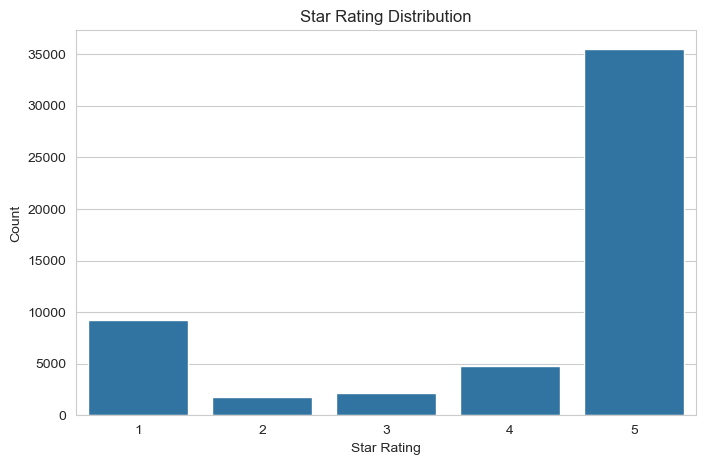

In [8]:
print(df['score'].value_counts().sort_index())
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='score'
)

plt.title('Star Rating Distribution')
plt.xlabel('Star Rating')
plt.ylabel('Count')

plt.show()

The distribution of star ratings across the dataset, revealing a significant positive bias with 5-star ratings being the most frequent by a large margin (over 35,000 counts). While there is a secondary spike in 1-star reviews representing dissatisfied users, the "middle" ground of 2, 3, and 4-star ratings is notably underrepresented. This indicates a class imbalance is a critical observation, as the model will be heavily exposed to extreme opinions rather than neutral feedback.

3. Star Ratings Per App
- This section compares rating behavior across different fintech applications to identify apps with higher complaint levels or customer satisfaction.

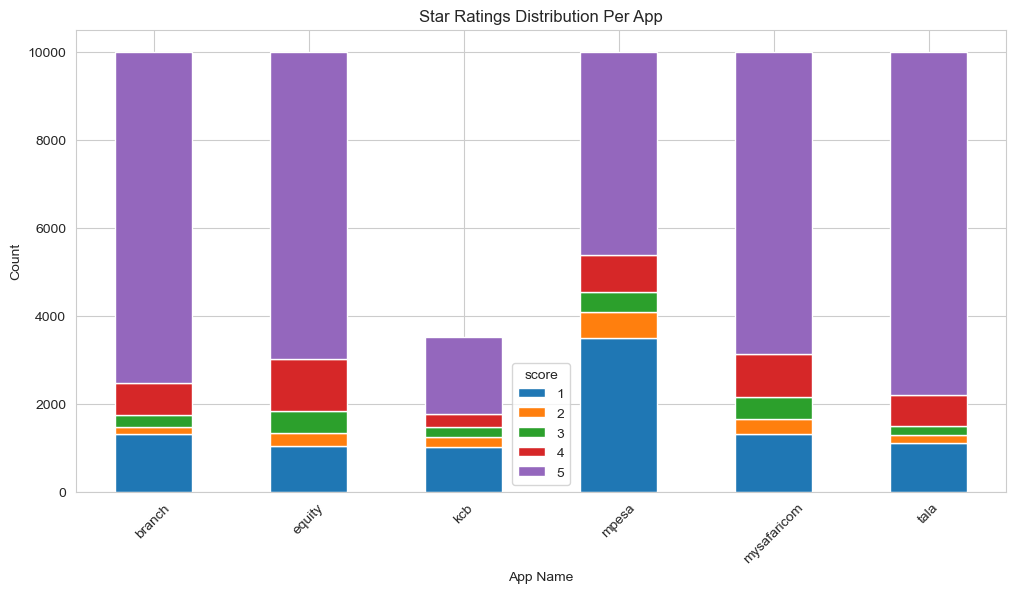

In [9]:
ratings_by_app = pd.crosstab(
    df['app_name'],
    df['score']
)

ratings_by_app.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Star Ratings Distribution Per App')
plt.xlabel('App Name')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

While most apps are dominated by 5-star reviews, user sentiment varies significantly across the platforms. The mpesa app stands out for having the highest volume of 1-star ratings, suggesting a higher level of user friction or technical dissatisfaction compared to its peers. Apps like branch and tala show a much larger proportion of 5-star reviews, indicating a generally more favorable reception within this specific dataset.

4. Review Length Feature (based on Character Length)

- Review length reflects complaint severity or customer engagement. Longer reviews often contain detailed complaints or service explanations.

In [10]:
df['review_length'] = df['content'].str.len()

df[['content', 'review_length']].head()

,content,review_length
0,"The app still has issues on OTP, because I hav...",311.0
1,si everytime nitakuwa na bundles za ku check m...,196.0
2,this is the stupidest app ever from saf. the w...,50.0
3,Life must go on without this useless app. It u...,125.0
4,the upgrade is terrible,23.0


5. Review Length Distribution

- How detailed customer feedback tends to be across the dataset.

Average Review Length:
42.62


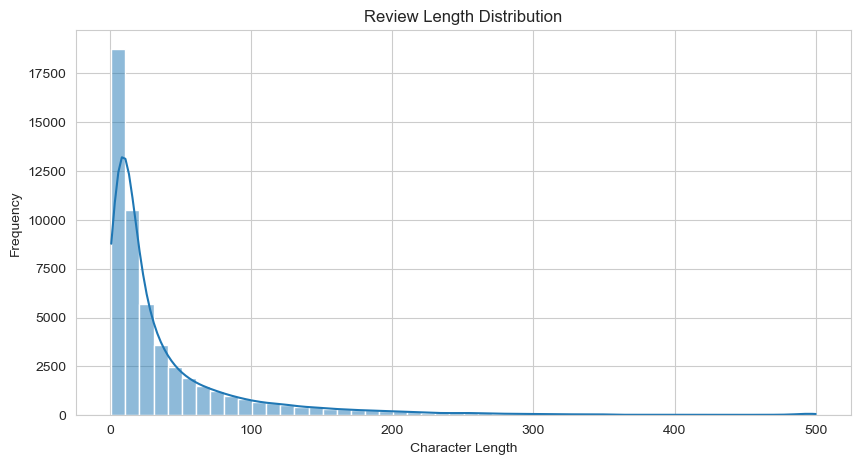

In [11]:
average_review_length = df['review_length'].mean()

print("Average Review Length:")

print(round(average_review_length, 2))
plt.figure(figsize=(10,5))

sns.histplot(
    df['review_length'],
    bins=50,
    kde=True
)

plt.title('Review Length Distribution')
plt.xlabel('Character Length')
plt.ylabel('Frequency')

plt.show()

6. Word count distrubution

In [12]:
df['word_count'] = df['content'].fillna('').apply(lambda x: len(str(x).split()))

print(df[['content', 'word_count']].head())

                                             content  word_count
0  The app still has issues on OTP, because I hav...          59
1  si everytime nitakuwa na bundles za ku check m...          42
2  this is the stupidest app ever from saf. the w...          10
3  Life must go on without this useless app. It u...          27
4                            the upgrade is terrible           4


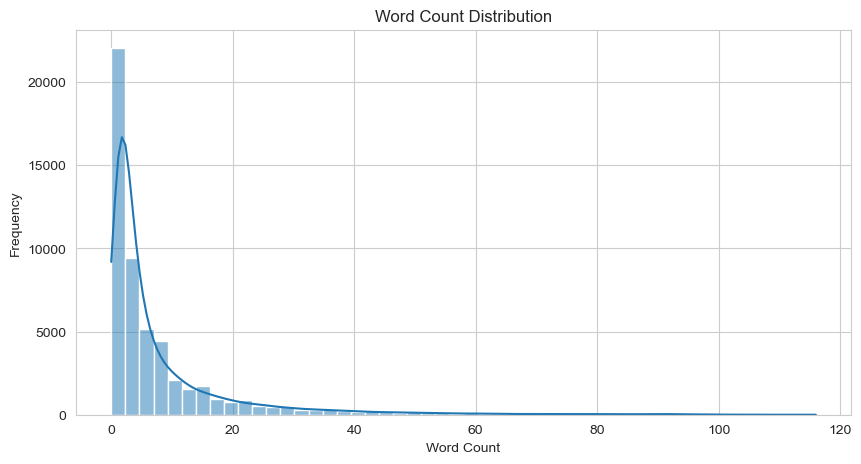

In [13]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['word_count'],
    bins=50,
    kde=True
)

plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.show()

7. Average word count
- summarizes the typical size of customer reviews within the dataset.

In [14]:
average_word_count = df['word_count'].mean()

print("Average Word Count:")

print(round(average_word_count, 2))

Average Word Count:
8.0


8. Summary statistics

In [15]:
summary_stats = df[[
    'score',
    'review_length',
    'word_count'
]].describe()

summary_stats

,score,review_length,word_count
count,53507.000000,53506.000000,53507.000000
mean,4.037846,42.620286,7.998916
std,1.547552,66.305219,12.263332
min,1.000000,1.000000,0.000000
25%,4.000000,8.000000,2.000000
50%,5.000000,17.000000,3.000000
75%,5.000000,46.000000,9.000000
max,5.000000,500.000000,116.000000


9. Average Review Length by Rating

- This analysis investigates whether level of dissatisfied influence length of reviews.

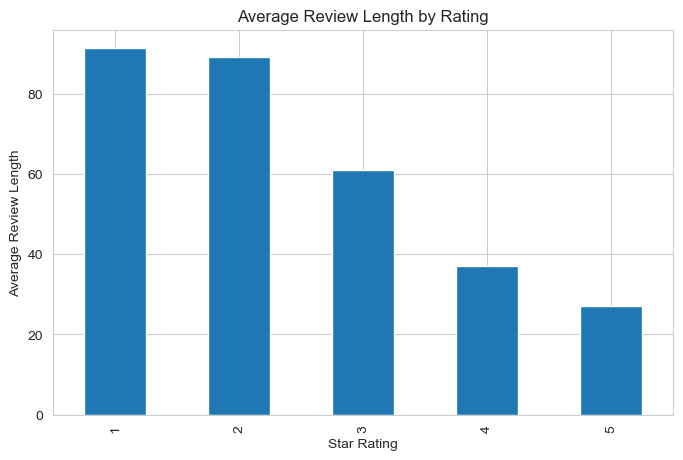

In [16]:
avg_length_by_rating = df.groupby('score')[
    'review_length'
].mean()

plt.figure(figsize=(8,5))

avg_length_by_rating.plot(kind='bar')

plt.title('Average Review Length by Rating')
plt.xlabel('Star Rating')
plt.ylabel('Average Review Length')

plt.show()

#### Key Insights
- Most important findings from the dataset.

In [17]:
print("- Most reviewed app:")
print(df['app_name'].value_counts().idxmax())

print("- Most common star rating:")
print(df['score'].mode()[0])

print("- Average review length:")
print(round(df['review_length'].mean(), 2))

print("- Average word count:")
print(round(df['word_count'].mean(), 2))

- Most reviewed app:
mpesa
- Most common star rating:
5
- Average review length:
42.62
- Average word count:
8.0
